In [16]:
# Importing libraries

from __future__ import print_function
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn import tree
import warnings
warnings.filterwarnings('ignore')

In [17]:
df = pd.read_csv("data.csv")

In [18]:
df.head()

,humidity,temperature,spo2,bp,dosha
0,63.76,37.86,96.06,154.53,1
1,67.71,37.33,95.30,106.90,0
2,60.81,37.75,96.86,112.64,0
3,41.24,37.25,90.21,92.69,1
4,60.19,36.50,94.11,147.67,0


In [19]:
df.tail()

,humidity,temperature,spo2,bp,dosha
4995,52.86,37.01,95.60,114.22,0
4996,64.04,38.02,99.10,113.03,0
4997,34.78,36.01,98.51,107.04,2
4998,36.70,36.50,91.36,128.98,1
4999,31.33,36.29,98.68,140.12,2


In [20]:
df.size

25000

In [21]:
df.shape

(5000, 5)

In [22]:
df.columns

Index(['humidity', 'temperature', 'spo2', 'bp', 'dosha'], dtype='object')

In [23]:
df['dosha'].unique()

array([1, 0, 2], dtype=int64)

In [24]:
df.dtypes

humidity       float64
temperature    float64
spo2           float64
bp             float64
dosha            int64
dtype: object

In [25]:
df['dosha'].value_counts()

dosha
1    2522
0    2312
2     166
Name: count, dtype: int64

<Axes: >

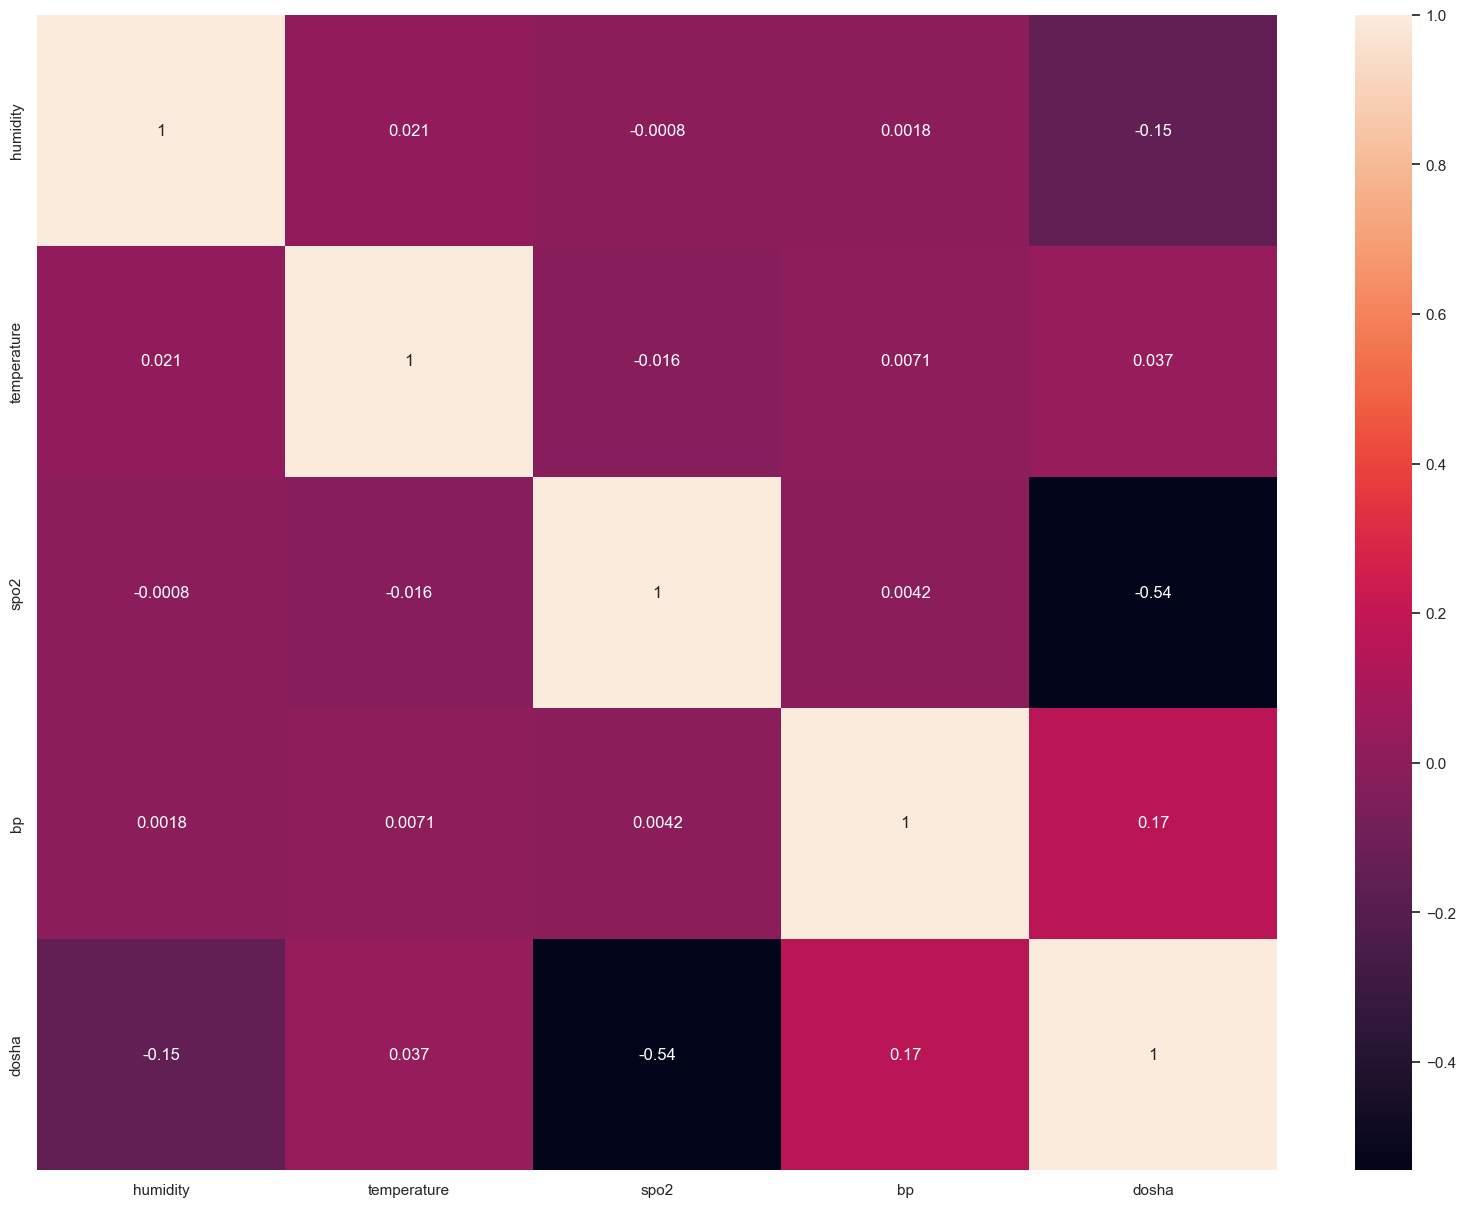

In [26]:
sns.set(rc = {'figure.figsize':(20,15)})
sns.heatmap(df.corr(),annot=True)

### Seperating features and target label

In [27]:
features = df[['humidity', 'temperature', 'spo2', 'bp']]
target = df['dosha']


In [28]:
# Initialzing empty lists to append all model's name and corresponding name
acc = []
model = []

In [29]:
# Splitting into train and test data

from sklearn.model_selection import train_test_split
Xtrain, Xtest, Ytrain, Ytest = train_test_split(features,target,test_size = 0.2,random_state =2)

# Decision Tree

In [30]:
from sklearn.tree import DecisionTreeClassifier

DecisionTree = DecisionTreeClassifier(criterion="entropy",random_state=2,max_depth=5)

DecisionTree.fit(Xtrain,Ytrain)

predicted_values = DecisionTree.predict(Xtest)
x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Decision Tree')
print("DecisionTrees's Accuracy is: ", x*100)

print(classification_report(Ytest,predicted_values))

DecisionTrees's Accuracy is:  100.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       483
           1       1.00      1.00      1.00       486
           2       1.00      1.00      1.00        31

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [31]:
from sklearn.model_selection import cross_val_score

In [32]:
# Cross validation score (Decision Tree)
score = cross_val_score(DecisionTree, features, target,cv=5)

In [33]:
score

array([1.   , 0.998, 1.   , 1.   , 1.   ])

### Saving trained Decision Tree model

In [34]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
DT_pkl_filename = 'DecisionTree.pkl'
# Open the file to save as pkl file
DT_Model_pkl = open(DT_pkl_filename, 'wb')
pickle.dump(DecisionTree, DT_Model_pkl)
# Close the pickle instances
DT_Model_pkl.close()

# Guassian Naive Bayes

In [35]:
from sklearn.naive_bayes import GaussianNB

NaiveBayes = GaussianNB()

NaiveBayes.fit(Xtrain,Ytrain)

predicted_values = NaiveBayes.predict(Xtest)
x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Naive Bayes')
print("Naive Bayes's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))

Naive Bayes's Accuracy is:  0.861
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       483
           1       0.85      0.87      0.86       486
           2       0.93      0.87      0.90        31

    accuracy                           0.86      1000
   macro avg       0.88      0.86      0.87      1000
weighted avg       0.86      0.86      0.86      1000



In [36]:
# Cross validation score (NaiveBayes)
score = cross_val_score(NaiveBayes,features,target,cv=5)
score

array([0.854, 0.872, 0.839, 0.858, 0.849])

### Saving trained Guassian Naive Bayes model

In [37]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
NB_pkl_filename = 'NBClassifier.pkl'
# Open the file to save as pkl file
NB_Model_pkl = open(NB_pkl_filename, 'wb')
pickle.dump(NaiveBayes, NB_Model_pkl)
# Close the pickle instances
NB_Model_pkl.close()

# Support Vector Machine (SVM)

In [38]:
from sklearn.svm import SVC
# data normalization with sklearn
from sklearn.preprocessing import MinMaxScaler
# fit scaler on training data
norm = MinMaxScaler().fit(Xtrain)
X_train_norm = norm.transform(Xtrain)
# transform testing dataabs
X_test_norm = norm.transform(Xtest)
SVM = SVC(kernel='poly', degree=3, C=1)
SVM.fit(X_train_norm,Ytrain)
predicted_values = SVM.predict(X_test_norm)
x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('SVM')
print("SVM's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))

SVM's Accuracy is:  0.869
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       483
           1       0.84      0.93      0.88       486
           2       0.83      0.77      0.80        31

    accuracy                           0.87      1000
   macro avg       0.86      0.84      0.85      1000
weighted avg       0.87      0.87      0.87      1000



In [39]:
# Cross validation score (SVM)
score = cross_val_score(SVM,features,target,cv=5)
score

array([0.837, 0.841, 0.835, 0.847, 0.84 ])

In [40]:
#Saving trained SVM model

In [41]:
import pickle
# Dump the trained SVM classifier with Pickle
SVM_pkl_filename = 'SVMClassifier.pkl'
# Open the file to save as pkl file
SVM_Model_pkl = open(SVM_pkl_filename, 'wb')
pickle.dump(SVM, SVM_Model_pkl)
# Close the pickle instances
SVM_Model_pkl.close()

# Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(n_estimators=20, random_state=0)
RF.fit(Xtrain,Ytrain)

predicted_values = RF.predict(Xtest)

x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('RF')
print("RF's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))

RF's Accuracy is:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       483
           1       1.00      1.00      1.00       486
           2       1.00      1.00      1.00        31

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [43]:
# Cross validation score (Random Forest)
score = cross_val_score(RF,features,target,cv=5)
score

array([1.   , 0.998, 1.   , 1.   , 0.999])

### Saving trained Random Forest model

In [44]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
RF_pkl_filename = 'RandomForest.pkl'
# Open the file to save as pkl file
RF_Model_pkl = open(RF_pkl_filename, 'wb')
pickle.dump(RF, RF_Model_pkl)
# Close the pickle instances
RF_Model_pkl.close()

## Accuracy Comparison

<Axes: title={'center': 'Accuracy Comparison'}, xlabel='Accuracy', ylabel='Algorithm'>

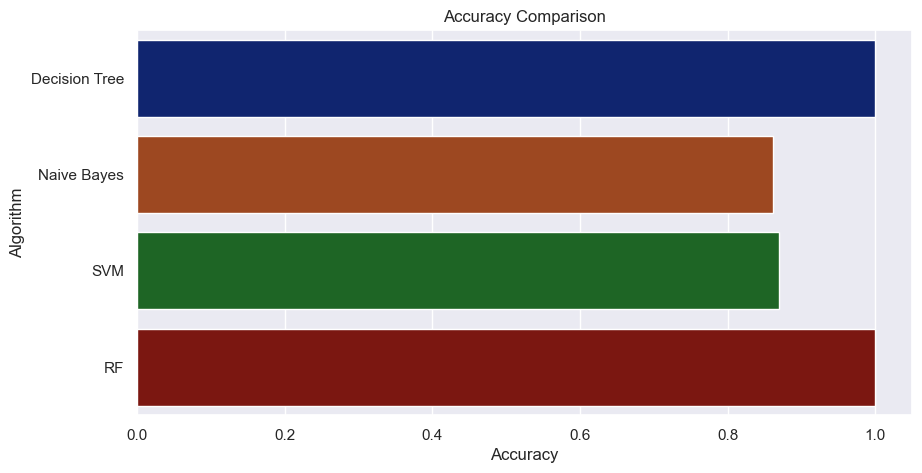

In [45]:
plt.figure(figsize=[10,5],dpi = 100)
plt.title('Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Algorithm')
sns.barplot(x = acc,y = model,palette='dark')

In [46]:
accuracy_models = dict(zip(model, acc))
for k, v in accuracy_models.items():
    print (k, '-->', v)

Decision Tree --> 1.0
Naive Bayes --> 0.861
SVM --> 0.869
RF --> 1.0


## Making a prediction

In [47]:
import pickle
import numpy as np
mod=pickle.load(open('RandomForest.pkl','rb'))
data = np.array([[60.19,36.5,94.11,147.67]])
prediction = mod.predict(data)[0]
print(prediction)

0


In [48]:
data = np.array([[36.5,36.73,90.21,100.76]])
prediction = mod.predict(data)[0]
print(prediction)

1


In [49]:
data = np.array([[32.43,36.22,96.43,154.08]])
prediction = mod.predict(data)[0]
print(prediction)

2
